# Cyclistic Case Study: Casual Riders vs Annual Members

## Introduction

This case study examines how casual riders and annual members use Cyclistic bikes differently.

## Business Task

**How do annual members and casual riders use Cyclistic bikes differently?**

In [1]:
import os
os.environ["MPLCONFIGDIR"] = os.path.join(os.getcwd(), ".mplconfig")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

## Data Import

The 2019 Cyclistic trip data is stored across four quarterly CSV files. In this section, each file is loaded into a separate dataframe so that the data structure can be reviewed before combining the datasets.

The final dataset contained 3,818,004 rows and 12 columns.



In [2]:

q1 = pd.read_csv('../data/cyclistic_trips_2019_q1.csv')
q2 = pd.read_csv('../data/cyclistic_trips_2019_q2.csv')
q3 = pd.read_csv('../data/cyclistic_trips_2019_q3.csv')
q4 = pd.read_csv('../data/cyclistic_trips_2019_q4.csv')

## Schema Alignment and Data Consolidation

Because the quarterly files do not all use the same column names, the schemas must be aligned before the datasets can be combined. After renaming the necessary columns, all four quarterly datasets are concatenated into a single dataframe called `all_trips`.

In [3]:
print(q1.columns.tolist())
print(q2.columns.tolist())

['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration', 'from_station_id', 'from_station_name', 'to_station_id', 'to_station_name', 'usertype', 'gender', 'birthyear']
['01 - Rental Details Rental ID', '01 - Rental Details Local Start Time', '01 - Rental Details Local End Time', '01 - Rental Details Bike ID', '01 - Rental Details Duration In Seconds Uncapped', '03 - Rental Start Station ID', '03 - Rental Start Station Name', '02 - Rental End Station ID', '02 - Rental End Station Name', 'User Type', 'Member Gender', '05 - Member Details Member Birthday Year']


In [4]:
q2 = q2.rename(columns={
    '01 - Rental Details Rental ID': 'trip_id',
    '01 - Rental Details Local Start Time': 'start_time',
    '01 - Rental Details Local End Time': 'end_time',
    '01 - Rental Details Bike ID': 'bikeid',
    '01 - Rental Details Duration In Seconds Uncapped': 'tripduration',
    '03 - Rental Start Station ID': 'from_station_id',
    '03 - Rental Start Station Name': 'from_station_name',
    '02 - Rental End Station ID': 'to_station_id',
    '02 - Rental End Station Name': 'to_station_name',
    'User Type': 'usertype',
    'Member Gender': 'gender',
    '05 - Member Details Member Birthday Year': 'birthyear'
})

In [5]:
print(q1.head())
print(q2.head())

    trip_id           start_time             end_time  bikeid tripduration  \
0  21742443  2019-01-01 00:04:37  2019-01-01 00:11:07    2167        390.0   
1  21742444  2019-01-01 00:08:13  2019-01-01 00:15:34    4386        441.0   
2  21742445  2019-01-01 00:13:23  2019-01-01 00:27:12    1524        829.0   
3  21742446  2019-01-01 00:13:45  2019-01-01 00:43:28     252      1,783.0   
4  21742447  2019-01-01 00:14:52  2019-01-01 00:20:56    1170        364.0   

   from_station_id                    from_station_name  to_station_id  \
0              199               Wabash Ave & Grand Ave             84   
1               44               State St & Randolph St            624   
2               15                 Racine Ave & 18th St            644   
3              123       California Ave & Milwaukee Ave            176   
4              173  Mies van der Rohe Way & Chicago Ave             35   

                  to_station_name    usertype  gender  birthyear  
0       Milwaukee A

In [6]:
all_trips = pd.concat([q1, q2, q3, q4], ignore_index=True)
all_trips.head()

,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,390.0,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Subscriber,Male,1989.0
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,441.0,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Subscriber,Female,1990.0
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,829.0,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Subscriber,Female,1994.0
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,"1,783.0",123,California Ave & Milwaukee Ave,176,Clark St & Elm St,Subscriber,Male,1993.0
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,364.0,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Subscriber,Male,1994.0


## Feature Engineering

After the datasets are combined, additional variables are created to support analysis. These include ride length in minutes, date, month, day of week, and hour of day. These fields make it easier to compare rider behavior across time patterns and trip duration.

In [7]:

# 1) Parse datetimes
all_trips["start_time"] = pd.to_datetime(all_trips["start_time"], errors="coerce")
all_trips["end_time"] = pd.to_datetime(all_trips["end_time"], errors="coerce")

# 2) Compute ride length in minutes
all_trips["ride_length_minutes"] = (
    all_trips["end_time"] - all_trips["start_time"]
).dt.total_seconds() / 60

# 3) Calendar features
all_trips["date"] = all_trips["start_time"].dt.date
all_trips["month"] = all_trips["start_time"].dt.to_period("M").astype(str)
all_trips["day_of_week"] = all_trips["start_time"].dt.day_name()
all_trips["hour"] = all_trips["start_time"].dt.hour

# 4) Drop fully empty rental detail columns if any exist
rental_cols = [c for c in all_trips.columns if "Rental Details" in c or c.startswith("0")]
all_nan_rental_cols = [c for c in rental_cols if all_trips[c].isna().all()]
all_trips.drop(columns=all_nan_rental_cols, inplace=True)

print(all_trips.shape)
print(all_nan_rental_cols[:10])

(3818004, 17)
[]


## Data Cleaning and Preparation for Analysis

The combined dataset is copied into a new dataframe called `df_clean`, which is used for the final analysis. Invalid or missing ride lengths are removed, ride durations are limited to a reasonable range, and the dataset is filtered to include only the two rider types relevant to the business question: `Subscriber` and `Customer`.

The day-of-week field is also converted into an ordered categorical variable so visualizations display weekdays in calendar order rather than alphabetical order.


In [8]:

df_clean = all_trips.copy()

df_clean = df_clean.loc[df_clean["ride_length_minutes"].notna()].copy()
df_clean = df_clean.loc[df_clean["ride_length_minutes"].between(1, 24 * 60)].copy()
df_clean = df_clean.loc[df_clean["usertype"].isin(["Subscriber", "Customer"])].copy()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df_clean["day_of_week"] = pd.Categorical(df_clean["day_of_week"], categories=day_order, ordered=True)

print(df_clean.shape)
print(df_clean["usertype"].value_counts())
print(df_clean[["usertype", "ride_length_minutes", "day_of_week"]].head())

(3816142, 17)
usertype
Subscriber    2936859
Customer       879283
Name: count, dtype: int64
     usertype  ride_length_minutes day_of_week
0  Subscriber             6.500000     Tuesday
1  Subscriber             7.350000     Tuesday
2  Subscriber            13.816667     Tuesday
3  Subscriber            29.716667     Tuesday
4  Subscriber             6.066667     Tuesday


## Exploratory Analysis

This section compares casual riders and annual members across ride duration, weekly ride volume, hourly usage patterns, and popular starting stations. The goal is to identify consistent differences in rider behavior that can support marketing recommendations.

### Ride Duration Interpretation

**This chart shows that casual riders generally take longer trips than annual members across the week.** This pattern suggests that casual riders are more likely to use Cyclistic for leisure or occasional trips, while annual members may rely more on the service for shorter, more practical trips such as commuting.

The difference in ride length supports the idea that the two rider groups use Cyclistic for different purposes, which is important when designing targeted membership strategies.

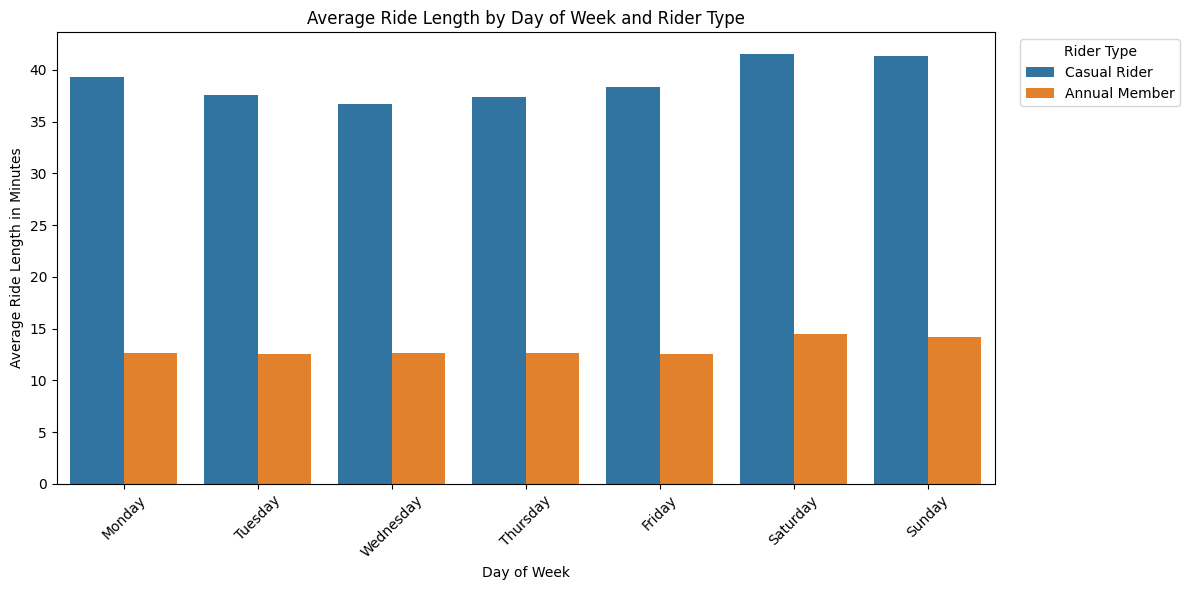

In [9]:


weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

avg_ride = df_clean.groupby(['day_of_week', 'usertype'])['ride_length_minutes'].mean().reset_index()
avg_ride['day_of_week'] = pd.Categorical(avg_ride['day_of_week'], categories=weekday_order, ordered=True)
avg_ride = avg_ride.sort_values('day_of_week')

avg_ride['usertype'] = avg_ride['usertype'].replace({
    'Customer': 'Casual Rider',
    'Subscriber': 'Annual Member'
})

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_ride, x='day_of_week', y='ride_length_minutes', hue='usertype')

plt.title('Average Ride Length by Day of Week and Rider Type')
plt.xlabel('Day of Week')
plt.ylabel('Average Ride Length in Minutes')
plt.xticks(rotation=45)
plt.legend(title='Rider Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()


## This chart shows that casual riders consistently take longer rides than annual members across the week. The pattern suggests that casual riders are more likely to use Cyclistic for leisure and recreational trips, while annual members appear to use it for shorter, more routine transportation needs.

### Weekly Ride Volume Interpretation

**This chart shows that annual members take more rides overall, especially on weekdays, while casual riders are relatively more active on weekends.** This pattern suggests that annual members are more likely to use Cyclistic as part of a regular routine, while casual riders may be using the service more for recreation or flexible weekend travel.

These differences reinforce the idea that membership is more closely associated with habitual transportation use.

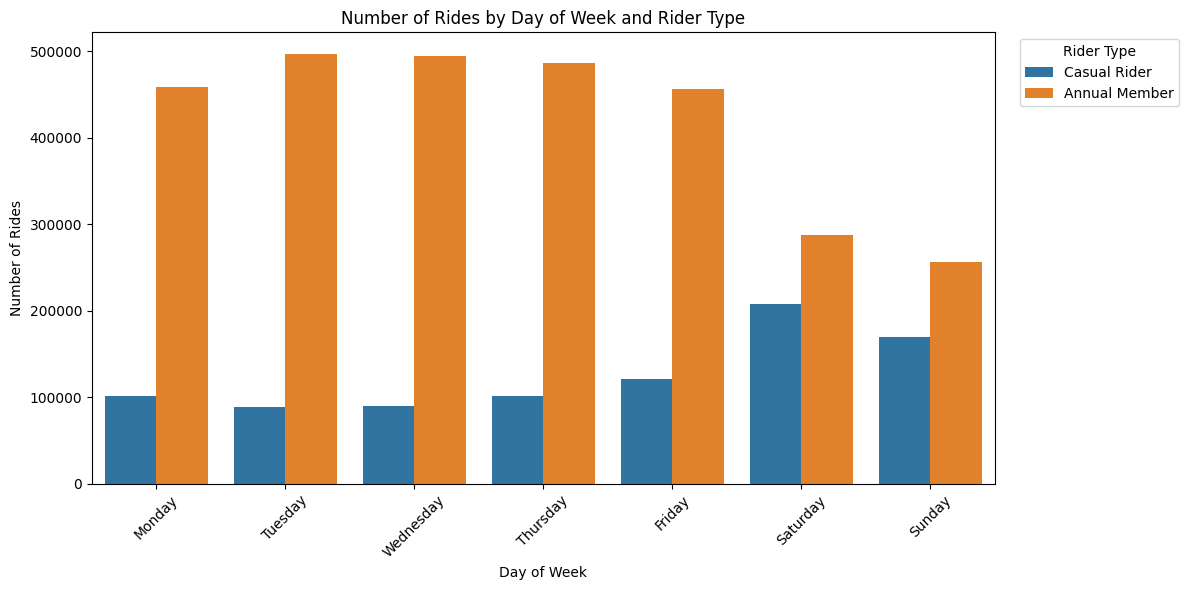

In [10]:

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

ride_counts = df_clean.groupby(['day_of_week', 'usertype']).size().reset_index(name='number_of_rides')
ride_counts['day_of_week'] = pd.Categorical(ride_counts['day_of_week'], categories=weekday_order, ordered=True)
ride_counts = ride_counts.sort_values('day_of_week')

ride_counts['usertype'] = ride_counts['usertype'].replace({
    'Customer': 'Casual Rider',
    'Subscriber': 'Annual Member'
})

plt.figure(figsize=(12, 6))
sns.barplot(data=ride_counts, x='day_of_week', y='number_of_rides', hue='usertype')

plt.title('Number of Rides by Day of Week and Rider Type')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.legend(title='Rider Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## This chart highlights differences in ride frequency between rider types across the week. Annual members appear to ride more consistently as part of regular transportation patterns, while casual rider activity reflects a more occasional and likely leisure-oriented pattern.


### Hourly Usage Pattern Interpretation

**This chart highlights clear differences in ride timing between casual riders and annual members.** Annual members show stronger peaks in the morning and late afternoon, suggesting commuter-style usage. Casual riders are more active from late morning through early evening, indicating a more flexible and leisure-oriented pattern.

Because the y-axis shows each hour's **share of total rides within each rider type**, the chart compares *when* each group rides rather than *how many* rides each group takes overall.

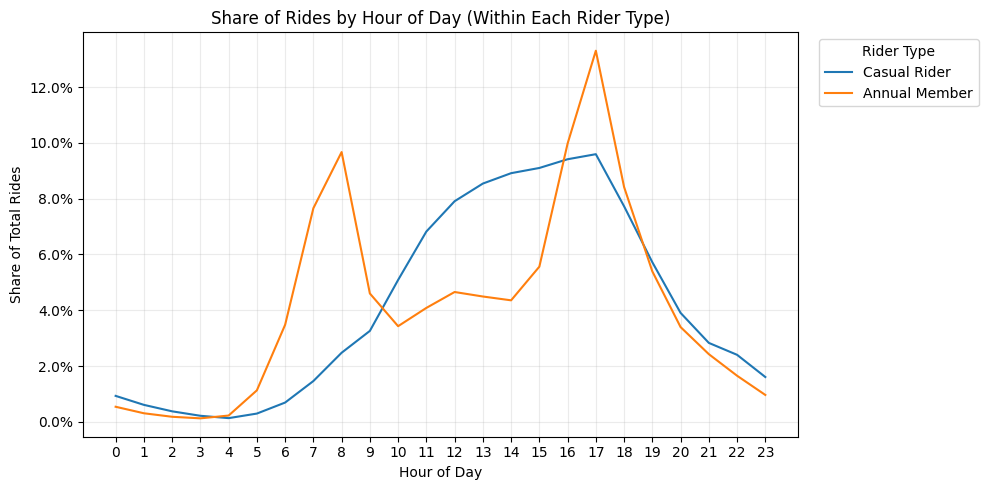

In [11]:



hour_counts = (
    df_clean.groupby(["usertype", "hour"])
    .size()
    .reset_index(name="rides")
)

hour_counts["share"] = (
    hour_counts["rides"] /
    hour_counts.groupby("usertype")["rides"].transform("sum")
)

hour_counts["usertype"] = hour_counts["usertype"].replace({
    "Customer": "Casual Rider",
    "Subscriber": "Annual Member"
})

plt.figure(figsize=(10, 5))
sns.lineplot(data=hour_counts, x="hour", y="share", hue="usertype")

plt.title("Share of Rides by Hour of Day (Within Each Rider Type)")
plt.xlabel("Hour of Day")
plt.ylabel("Share of Total Rides")
plt.xticks(range(0, 24))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True, alpha=0.25)
plt.legend(title="Rider Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## This chart highlights differences in hourly ride patterns between casual riders and annual members.

### Casual Rider Start Station Interpretation

**This chart identifies the stations most frequently used by casual riders at the start of their trips.** If these stations are concentrated near popular destinations, parks, or downtown leisure areas, that would support the idea that casual riders are more likely to use Cyclistic for recreational or occasional travel.

These stations may also present strong opportunities for location-based marketing to convert casual riders into annual members.

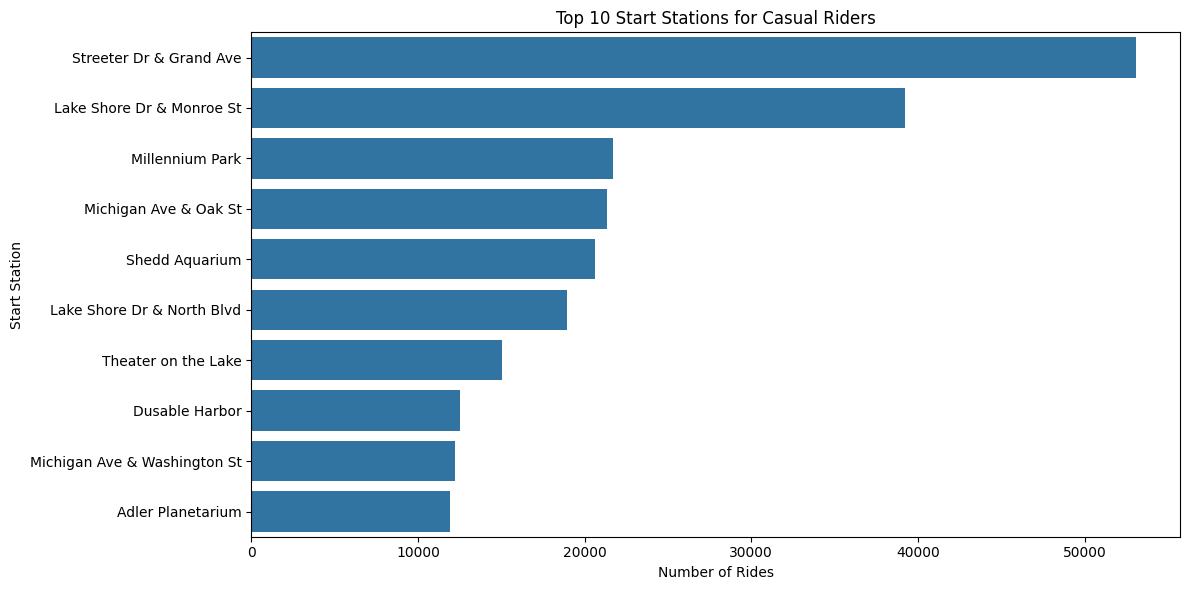

In [12]:
customer_stations = (
    df_clean[df_clean['usertype'] == 'Customer']['from_station_name']
    .value_counts()
    .head(10)
    .reset_index()
)

customer_stations.columns = ['from_station_name', 'number_of_rides']

plt.figure(figsize=(12, 6))
sns.barplot(data=customer_stations, x='number_of_rides', y='from_station_name')

plt.title('Top 10 Start Stations for Casual Riders')
plt.xlabel('Number of Rides')
plt.ylabel('Start Station')
plt.tight_layout()
plt.show()

### Annual Member Start Station Interpretation

**This chart identifies the stations most frequently used by annual members at the start of their trips.** If these stations are concentrated near business districts, transit connections, or dense residential areas, that would support the idea that annual members use Cyclistic more as part of regular transportation routines.

This pattern can help distinguish commuter-oriented behavior from the more leisure-oriented patterns seen among casual riders.

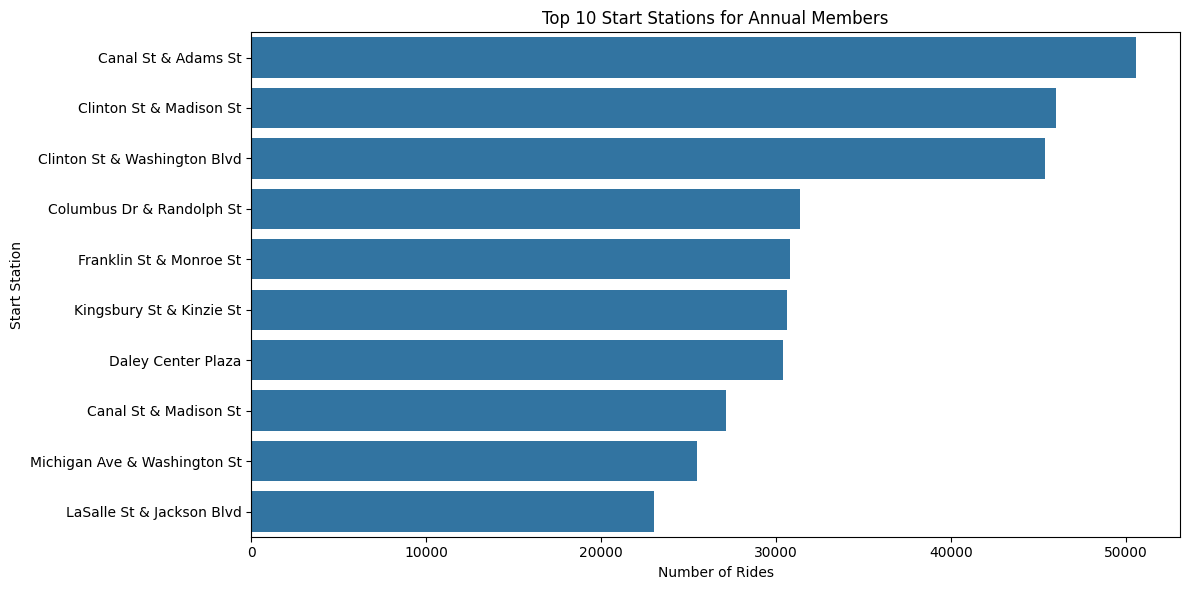

In [13]:
subscriber_stations = (
    df_clean[df_clean['usertype'] == 'Subscriber']['from_station_name']
    .value_counts()
    .head(10)
    .reset_index()
)

subscriber_stations.columns = ['from_station_name', 'number_of_rides']

plt.figure(figsize=(12, 6))
sns.barplot(data=subscriber_stations, x='number_of_rides', y='from_station_name')

plt.title('Top 10 Start Stations for Annual Members')
plt.xlabel('Number of Rides')
plt.ylabel('Start Station')
plt.tight_layout()
plt.show()

## These Charts show casual rider trips are concentrated around lakefront, tourist, and recreational locations such as Streeter Dr & Grand Ave, Millennium Park, and Shedd Aquarium. This suggests that many casual riders use Cyclistic bikes for sightseeing, weekend outings, and other leisure activities. While Annual rider trips are concentrated around Canal, Adams, and Madison St. This suggest that many annual riders use Cyclistic for business.

## Key Findings

**The analysis shows clear behavioral differences between casual riders and annual members.** Annual members take more rides overall and show stronger activity during weekdays and commute-oriented hours, especially in the morning and late afternoon. This suggests that members are more likely to use Cyclistic as part of a regular transportation routine.

**Casual riders, by contrast, tend to take longer trips and show relatively stronger activity during weekends and midday hours.** This pattern suggests a more flexible and leisure-oriented style of use, rather than consistent weekday commuting.

**The station analysis also supports the idea that the two rider groups may be starting trips in different types of locations.** Annual member activity appears more aligned with routine travel patterns, while casual rider activity may be more connected to recreational or occasional-use areas.

Taken together, these findings suggest that casual riders and annual members are not simply using Cyclistic at different volumes — they are using the service in meaningfully different ways. This distinction is important because any successful strategy to convert casual riders into annual members should reflect the motivations and riding habits of casual users rather than assuming they behave like existing members.

## Recommendations

Based on the observed behavioral differences, Cyclistic should focus on marketing strategies that encourage casual riders to see membership as valuable beyond occasional leisure use.

Possible strategies include promoting weekend riders with membership trials, offering incentives tied to frequent riding, targeting high-traffic casual-rider stations, and emphasizing cost savings for riders who use the service repeatedly over time.

## Next Steps 

Recommendation 1 — Weekend conversion push (Customer → Member)
Run membership conversion campaigns on Saturdays and Sundays (in-app prompts, kiosk screens, and station signage near parks, waterfronts, and tourist-heavy stations), because that’s when Customers are most active and most “convertible.” Evidence: In the share-by-day-of-week chart, Customers’ ride share spikes on the weekend (especially Saturday), while Subscribers skew toward weekdays.

Recommendation 2 — Price framing around longer rides
Market membership as a “save money on longer rides” plan, using a simple threshold message such as “If you ride longer than X minutes or ride more than Y times/month, membership pays for itself.” Evidence: In the ride length distribution (1–180 minutes) histogram, Customers have a visibly longer right tail than Subscribers, meaning a larger fraction of Customer trips are long enough for “you’d save with membership” messaging to be compelling.

Recommendation 3 — Time-of-day targeting (midday focus)
Trigger upsell offers during late morning through afternoon (and especially on weekends), and de-emphasize commute windows, since Customer riding is strongest midday and Subscriber riding dominates peak commute hours. Evidence: In the share-by-hour chart, Subscribers show sharp peaks around ~8 AM and ~5 PM, while Customers’ share is concentrated from late morning into the afternoon.

## Conclusion

**This analysis found that casual riders and annual members use Cyclistic bikes differently in terms of ride duration, ride timing, and weekly usage patterns.** Annual members appear to rely more on Cyclistic for regular and practical transportation, while casual riders show patterns that are more consistent with leisure and flexible use.

These differences suggest that Cyclistic should not market annual memberships to casual riders using the same assumptions that apply to current members. Instead, the company should build conversion strategies around the actual behavior of casual riders, especially their longer trips, weekend activity, and midday usage patterns.

By aligning marketing efforts with observed rider behavior, Cyclistic can make membership feel more relevant and attractive to casual users and improve its chances of increasing annual memberships.